In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
BASE_DIR = Path().resolve()  # or adjust if needed
RAW_DATA_DIR = BASE_DIR / "raw_data"
CLEANED_DATA_DIR = BASE_DIR / "cleaned_data"

START_DATE = "2015-01-01"
END_DATE = "2026-05-01"

PRICE_FILES = {
    "egx30": "EGX 30 Historical Data.csv",
    "egx100": "EGX 100 Historical Data.csv",
    "gold": "GAU_EGP Historical Data.csv",
    "tmg": "T M G Holding Stock Price History.csv",
    "sodic": "SODIC Stock Price History.csv",
    "palm_hills": "Palm Hills Develop Stock Price History.csv",
}

TBILL_FILE = "Egypt 1-Year Bond Yield Historical Data.csv"

In [4]:
def clean_price_file(name: str, filepath: Path, start: str, end: str) -> pd.DataFrame:
    print(f"[{name}] Reading {filepath.name}")
    df = pd.read_csv(filepath)

    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
    df.columns = [c.replace(".", "") for c in df.columns]
    df.columns = [c.replace("%", "pct") for c in df.columns]

    print(f"[{name}] Columns: {df.columns.tolist()}")

    df["date"] = pd.to_datetime(df["date"], format="%m/%d/%Y")
    df = df.set_index("date").sort_index()

    df = df.loc[start:end]

    for col in ["price", "open", "high", "low"]:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.strip()
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "vol" in df.columns:
        df["vol"] = (
            df["vol"]
            .astype(str)
            .str.replace("M", "", regex=False)
            .str.strip()
            .replace("-", pd.NA)
        )
        df["vol"] = pd.to_numeric(df["vol"], errors="coerce")

    if "change_pct" in df.columns:
        df["change_pct"] = (
            df["change_pct"]
            .astype(str)
            .str.replace("%", "", regex=False)
            .str.strip()
        )
        df["change_pct"] = pd.to_numeric(df["change_pct"], errors="coerce")

    print(f"[{name}] Done. Shape: {df.shape}")
    return df

In [5]:
def clean_tbill_file(filepath: Path, start: str, end: str) -> pd.DataFrame:
    print(f"[tbills] Reading {filepath.name}")
    df = pd.read_csv(filepath)

    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

    date_col = df.columns[0]
    df = df.rename(columns={date_col: "date"})

    df = df[["date", "price"]]

    df["date"] = pd.to_datetime(df["date"], format="%m/%d/%Y")
    df = df.set_index("date").sort_index()

    df = df.loc[start:end]

    df["price"] = (
        df["price"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip()
    )
    df["price"] = pd.to_numeric(df["price"], errors="coerce")

    print(f"[tbills] Done. Shape: {df.shape}")
    return df

In [6]:
cleaned_data = {}

# Prices
for name, file in PRICE_FILES.items():
    path = RAW_DATA_DIR / file
    cleaned_data[name] = clean_price_file(name, path, START_DATE, END_DATE)

# T-bills
tbill_path = RAW_DATA_DIR / TBILL_FILE
cleaned_data["tbills"] = clean_tbill_file(tbill_path, START_DATE, END_DATE)

[egx30] Reading EGX 30 Historical Data.csv
[egx30] Columns: ['date', 'price', 'open', 'high', 'low', 'vol', 'change_pct']
[egx30] Done. Shape: (2754, 6)
[egx100] Reading EGX 100 Historical Data.csv
[egx100] Columns: ['date', 'price', 'open', 'high', 'low', 'vol', 'change_pct']
[egx100] Done. Shape: (1306, 6)
[gold] Reading GAU_EGP Historical Data.csv
[gold] Columns: ['date', 'price', 'open', 'high', 'low', 'vol', 'change_pct']
[gold] Done. Shape: (559, 6)
[tmg] Reading T M G Holding Stock Price History.csv
[tmg] Columns: ['date', 'price', 'open', 'high', 'low', 'vol', 'change_pct']
[tmg] Done. Shape: (2755, 6)
[sodic] Reading SODIC Stock Price History.csv
[sodic] Columns: ['date', 'price', 'open', 'high', 'low', 'vol', 'change_pct']
[sodic] Done. Shape: (2753, 6)
[palm_hills] Reading Palm Hills Develop Stock Price History.csv
[palm_hills] Columns: ['date', 'price', 'open', 'high', 'low', 'vol', 'change_pct']
[palm_hills] Done. Shape: (2755, 6)
[tbills] Reading Egypt 1-Year Bond Yield H

In [22]:
for name, df in cleaned_data.items():
    out_path = CLEANED_DATA_DIR / f"{name}.csv"
    df.to_csv(out_path)
    print(f"Saved {name} → {out_path}")

Saved egx30 → C:\Users\moata\Documents\Investments\cleaned_data\egx30.csv
Saved egx100 → C:\Users\moata\Documents\Investments\cleaned_data\egx100.csv
Saved gold → C:\Users\moata\Documents\Investments\cleaned_data\gold.csv
Saved tmg → C:\Users\moata\Documents\Investments\cleaned_data\tmg.csv
Saved sodic → C:\Users\moata\Documents\Investments\cleaned_data\sodic.csv
Saved palm_hills → C:\Users\moata\Documents\Investments\cleaned_data\palm_hills.csv
Saved tbills → C:\Users\moata\Documents\Investments\cleaned_data\tbills.csv


In [7]:
cleaned_data['egx30'].head()

,price,open,high,low,vol,change_pct
date,,,,,,
2015-01-04,8942.65,8926.26,8942.65,8880.21,62.86,0.18
2015-01-05,9011.07,8941.72,9033.07,8931.80,86.76,0.77
2015-01-06,8798.94,8971.93,8971.93,8754.87,105.19,-2.35
2015-01-08,8946.34,8819.61,8954.29,8819.61,82.04,1.68
2015-01-11,8909.75,8945.69,8957.59,8909.75,45.71,-0.41


In [8]:
cleaned_data['egx30'].info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2754 entries, 2015-01-04 to 2026-04-30
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       2754 non-null   float64
 1   open        2754 non-null   float64
 2   high        2754 non-null   float64
 3   low         2754 non-null   float64
 4   vol         2743 non-null   float64
 5   change_pct  2754 non-null   float64
dtypes: float64(6)
memory usage: 150.6 KB


In [9]:
cleaned_data['egx100'].info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1306 entries, 2015-01-04 to 2020-05-07
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       1306 non-null   float64
 1   open        1306 non-null   float64
 2   high        1306 non-null   float64
 3   low         1306 non-null   float64
 4   vol         1294 non-null   float64
 5   change_pct  1306 non-null   float64
dtypes: float64(6)
memory usage: 71.4 KB


In [10]:
cleaned_data["gold"].info()

<class 'pandas.DataFrame'>
DatetimeIndex: 559 entries, 2024-05-21 to 2026-05-01
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       559 non-null    float64
 1   open        559 non-null    float64
 2   high        559 non-null    float64
 3   low         559 non-null    float64
 4   vol         0 non-null      float64
 5   change_pct  559 non-null    float64
dtypes: float64(6)
memory usage: 30.6 KB


In [11]:
cleaned_data["tbills"].info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3053 entries, 2015-01-01 to 2026-04-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   3053 non-null   float64
dtypes: float64(1)
memory usage: 47.7 KB


In [12]:
cleaned_data["tbills"].head(20)

,price
date,
2015-01-01,11.950
2015-01-02,11.950
2015-01-04,12.200
2015-01-05,11.950
2015-01-06,12.200
2015-01-07,11.950
2015-01-08,11.950
2015-01-09,11.950
2015-01-11,12.200


In [13]:
cleaned_data["tbills"]["price.L1"] =  cleaned_data["tbills"]["price"].shift(1)
cleaned_data["tbills"].dropna(inplace=True)

In [14]:
cleaned_data["tbills"].info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3052 entries, 2015-01-02 to 2026-04-30
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   price     3052 non-null   float64
 1   price.L1  3052 non-null   float64
dtypes: float64(2)
memory usage: 71.5 KB


In [15]:
cleaned_data["tbills"].head()

,price,price.L1
date,,
2015-01-02,11.95,11.95
2015-01-04,12.20,11.95
2015-01-05,11.95,12.20
2015-01-06,12.20,11.95
2015-01-07,11.95,12.20


<Axes: title={'center': 'Distribution of tbill price'}>

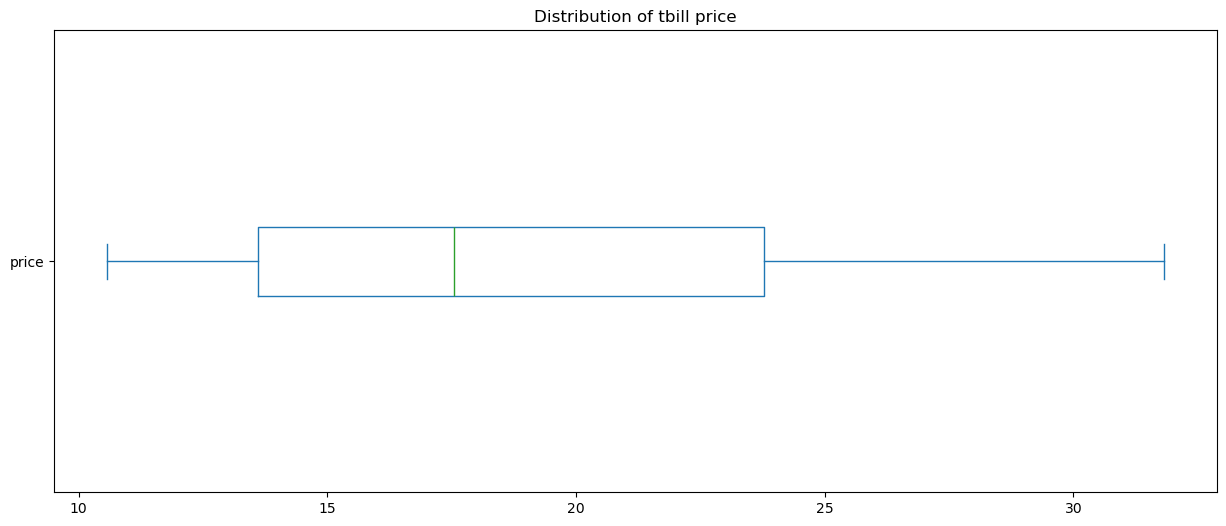

In [16]:
fig, ax = plt.subplots(figsize=(15, 6))

cleaned_data["tbills"]["price"].plot(kind="box", vert=False, title="Distribution of tbill price", ax=ax)

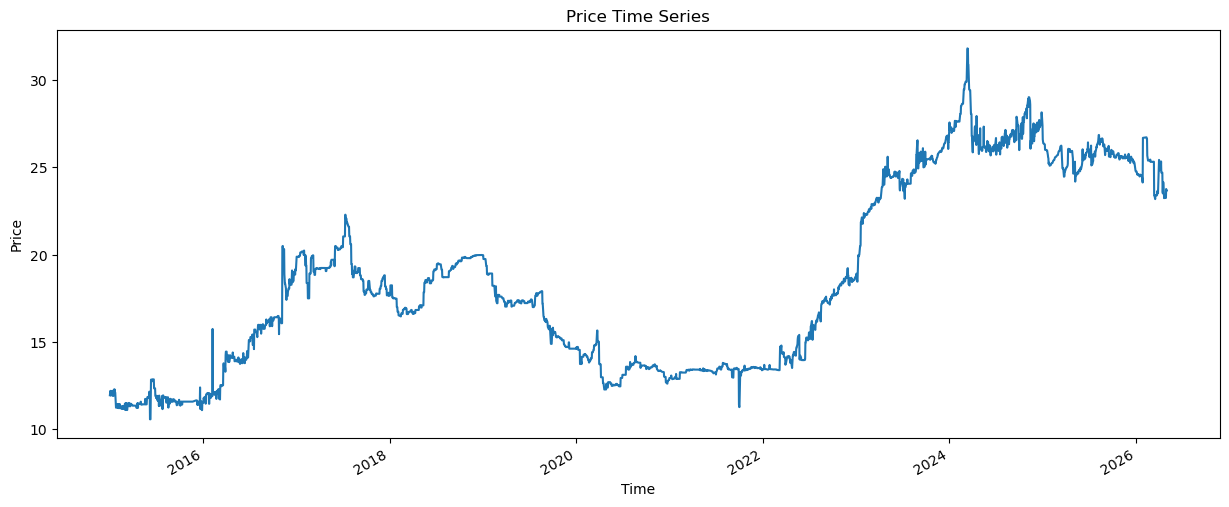

In [17]:
fig, ax = plt.subplots(figsize=(15, 6))

cleaned_data["tbills"]["price"].plot(xlabel= "Time", ylabel="Price",title="Price Time Series",ax=ax);

In [18]:
cleaned_data["tbills"].corr()

,price,price.L1
price,1.000000,0.998524
price.L1,0.998524,1.000000


Text(0.5, 1.0, 'Price Autocorrelation')

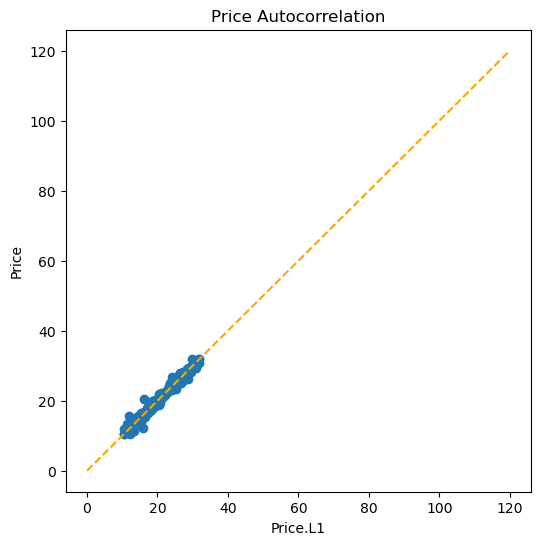

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(x=cleaned_data["tbills"]["price.L1"], y=cleaned_data["tbills"]["price"])
ax.plot([0, 120], [0, 120], linestyle="--", color="orange")
plt.xlabel("Price.L1")
plt.ylabel("Price")
plt.title("Price Autocorrelation")

In [20]:
print(cleaned_data)

{'egx30':                price      open      high       low     vol  change_pct
date                                                                  
2015-01-04   8942.65   8926.26   8942.65   8880.21   62.86        0.18
2015-01-05   9011.07   8941.72   9033.07   8931.80   86.76        0.77
2015-01-06   8798.94   8971.93   8971.93   8754.87  105.19       -2.35
2015-01-08   8946.34   8819.61   8954.29   8819.61   82.04        1.68
2015-01-11   8909.75   8945.69   8957.59   8909.75   45.71       -0.41
...              ...       ...       ...       ...     ...         ...
2026-04-26  52421.14  52375.39  52632.40  52327.40  699.41        0.09
2026-04-27  52719.12  52421.14  52865.76  52353.93  341.83        0.57
2026-04-28  52230.61  52719.12  52896.87  52213.64  402.73       -0.93
2026-04-29  52383.13  52230.61  52431.85  52096.15  420.47        0.29
2026-04-30  51760.97  52383.13  52538.84  51748.64  637.54       -1.19

[2754 rows x 6 columns], 'egx100':               price     open   